# ML Fundamentals #5: Support Vector Machine (SVM)

## Heart Disease Prediction using Support Vector Machine

This project implements a Support Vector Machine classifier to predict the presence of heart disease using patient clinical and diagnostic attributes.

The notebook covers:

- Data Loading
- Dataset Understanding
- Exploratory Data Analysis
- Data Preprocessing
- Feature Scaling
- SVM Model Training
- Prediction
- Model Evaluation
- Kernel Comparison
- Decision Boundary Analysis
- Hyperparameter Tuning
- Model Serialization

In [2]:
# Import required libraries for analysis, visualization, preprocessing, SVM modeling, and evaluation

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import joblib

In [3]:
# Create directories for models, figures, and tables

os.makedirs("models", exist_ok=True)
os.makedirs("outputs/figures", exist_ok=True)
os.makedirs("outputs/tables", exist_ok=True)

print("Project directories ready.")

Project directories ready.


## 2. Loading the Dataset

This project uses the Heart Disease dataset containing clinical attributes associated with cardiovascular health.

The objective is to classify whether a patient shows the presence or absence of heart disease using a Support Vector Machine classifier.

In [5]:
import pandas as pd

print(pd.__version__)

3.0.6


In [7]:
# Load the Cleveland Heart Disease dataset from the official UCI repository

dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

column_names = [
    "age", "sex", "cp", "trestbps", "chol", "fbs",
    "restecg", "thalach", "exang", "oldpeak",
    "slope", "ca", "thal", "target"
]

df = pd.read_csv(
    dataset_url,
    names=column_names,
    na_values="?"
)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [8]:
# Display the dataset dimensions and column names

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nFeatures:")
print(df.columns.tolist())

Rows: 303
Columns: 14

Features:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


In [9]:
# Save the raw dataset locally and export a preview table

df.to_csv("data/raw/heart_disease_cleveland.csv", index=False)

df.head(10).to_csv(
    "outputs/tables/dataset_preview.csv",
    index=False
)

print("Dataset saved successfully.")

Dataset saved successfully.


### Dataset Loading Insights

- The Cleveland Heart Disease dataset contains 303 patient records.
- It consists of 13 clinical predictor variables and one diagnosis target variable.
- Missing values represented by `?` in the original data were converted to standard missing values during loading.
- The original target ranges from 0 to 4, where 0 represents absence of heart disease and values 1–4 indicate its presence.
- A local copy of the dataset has been stored for reproducibility.

## 3. Understanding the Dataset

Before preprocessing and model training, the dataset is examined to understand its structure, feature types, statistical characteristics, data quality, and target distribution.

In [10]:
# Examine dataset structure, data types, and non-null values

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [11]:
# Generate descriptive statistics for all dataset features

dataset_summary = df.describe().T
dataset_summary

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


In [12]:
# Save descriptive statistics for later reference

dataset_summary.to_csv("outputs/tables/dataset_summary.csv")

In [13]:
# Check the number and percentage of missing values in each column

missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_values

,Missing Values,Missing Percentage
age,0,0.00
sex,0,0.00
cp,0,0.00
trestbps,0,0.00
chol,0,0.00
fbs,0,0.00
restecg,0,0.00
thalach,0,0.00
exang,0,0.00
oldpeak,0,0.00


In [14]:
# Save the missing-value analysis

missing_values.to_csv("outputs/tables/missing_values.csv")

In [15]:
# Check the dataset for duplicate patient records

duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [16]:
# Examine the original heart disease diagnosis values

target_distribution = df["target"].value_counts().sort_index()

print(target_distribution)

target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64


In [17]:
# Save the original target distribution

target_distribution.to_frame(
    name="Count"
).to_csv("outputs/tables/target_distribution_original.csv")

### Dataset Understanding Insights

- The dataset contains 303 observations with 13 predictor variables and one target variable.
- The predictors represent demographic, clinical, electrocardiographic, and exercise-related measurements.
- Missing-value analysis is necessary because the original Cleveland dataset contains unknown values in some attributes.
- Duplicate records are checked before preprocessing to avoid unnecessary repetition in the training data.
- The original diagnosis target uses values from 0 to 4.
- For binary SVM classification, the target will later be transformed into:
  - **0:** No heart disease
  - **1:** Presence of heart disease (original diagnosis 1–4)

## 4. Exploratory Data Analysis

Exploratory Data Analysis is performed to understand the distribution of heart disease cases, examine individual clinical features, and identify relationships among numerical variables before preprocessing and SVM training.

In [18]:
# Create a binary diagnosis variable for exploratory analysis

df_eda = df.copy()
df_eda["heart_disease"] = (df_eda["target"] > 0).astype(int)

df_eda["heart_disease"].value_counts()

heart_disease
0    164
1    139
Name: count, dtype: int64

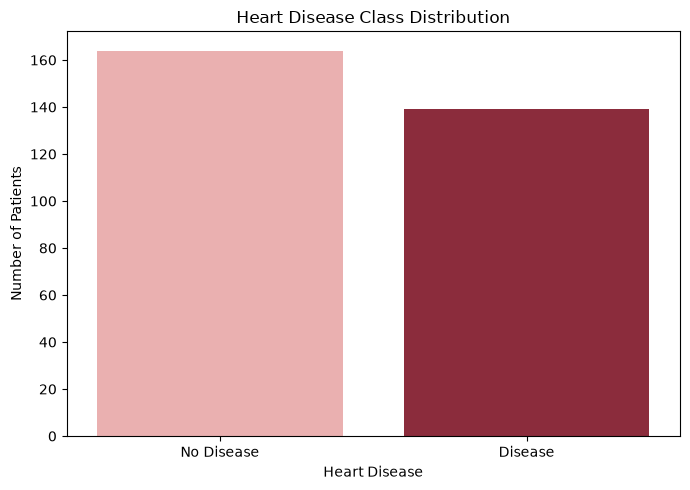

In [19]:
# Visualize the distribution of patients with and without heart disease

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df_eda,
    x="heart_disease",
    palette=["#F4A6A6", "#9B1C31"]
)

plt.title("Heart Disease Class Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Number of Patients")
plt.xticks([0, 1], ["No Disease", "Disease"])

plt.tight_layout()
plt.savefig("outputs/figures/target_distribution.png", dpi=300)
plt.show()

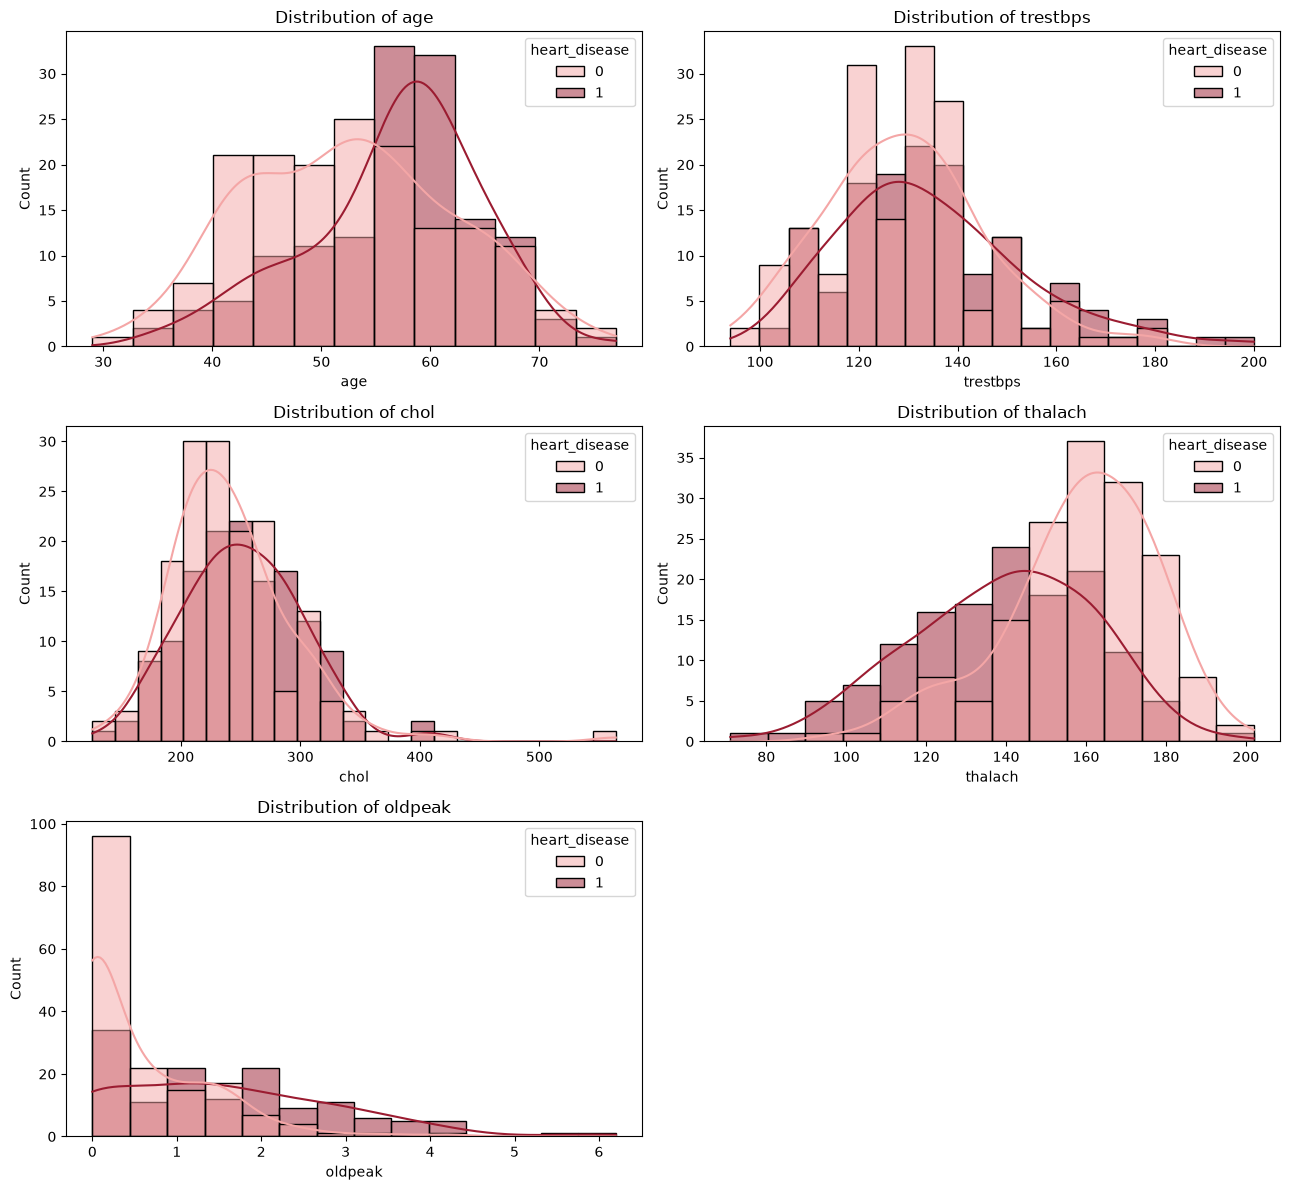

In [20]:
# Visualize distributions of the continuous clinical features

continuous_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

fig, axes = plt.subplots(3, 2, figsize=(13, 12))
axes = axes.flatten()

for i, feature in enumerate(continuous_features):
    sns.histplot(
        data=df_eda,
        x=feature,
        hue="heart_disease",
        kde=True,
        palette=["#F4A6A6", "#9B1C31"],
        ax=axes[i]
    )
    axes[i].set_title(f"Distribution of {feature}")

axes[-1].axis("off")

plt.tight_layout()
plt.savefig("outputs/figures/feature_distributions.png", dpi=300)
plt.show()

In [21]:
# Calculate correlations between numerical features

correlation_matrix = df_eda.corr(numeric_only=True)

correlation_matrix.to_csv(
    "outputs/tables/correlation_matrix.csv"
)

correlation_matrix.round(2)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,heart_disease
age,1.00,-0.10,0.10,0.28,0.21,0.12,0.15,-0.39,0.09,0.20,0.16,0.36,0.13,0.22,0.22
sex,-0.10,1.00,0.01,-0.06,-0.20,0.05,0.02,-0.05,0.15,0.10,0.04,0.09,0.38,0.22,0.28
cp,0.10,0.01,1.00,-0.04,0.07,-0.04,0.07,-0.33,0.38,0.20,0.15,0.23,0.27,0.41,0.41
trestbps,0.28,-0.06,-0.04,1.00,0.13,0.18,0.15,-0.05,0.06,0.19,0.12,0.10,0.13,0.16,0.15
chol,0.21,-0.20,0.07,0.13,1.00,0.01,0.17,-0.00,0.06,0.05,-0.00,0.12,0.01,0.07,0.09
fbs,0.12,0.05,-0.04,0.18,0.01,1.00,0.07,-0.01,0.03,0.01,0.06,0.15,0.07,0.06,0.03
restecg,0.15,0.02,0.07,0.15,0.17,0.07,1.00,-0.08,0.08,0.11,0.13,0.13,0.02,0.18,0.17
thalach,-0.39,-0.05,-0.33,-0.05,-0.00,-0.01,-0.08,1.00,-0.38,-0.34,-0.39,-0.26,-0.28,-0.42,-0.42
exang,0.09,0.15,0.38,0.06,0.06,0.03,0.08,-0.38,1.00,0.29,0.26,0.15,0.33,0.40,0.43
oldpeak,0.20,0.10,0.20,0.19,0.05,0.01,0.11,-0.34,0.29,1.00,0.58,0.30,0.34,0.50,0.42


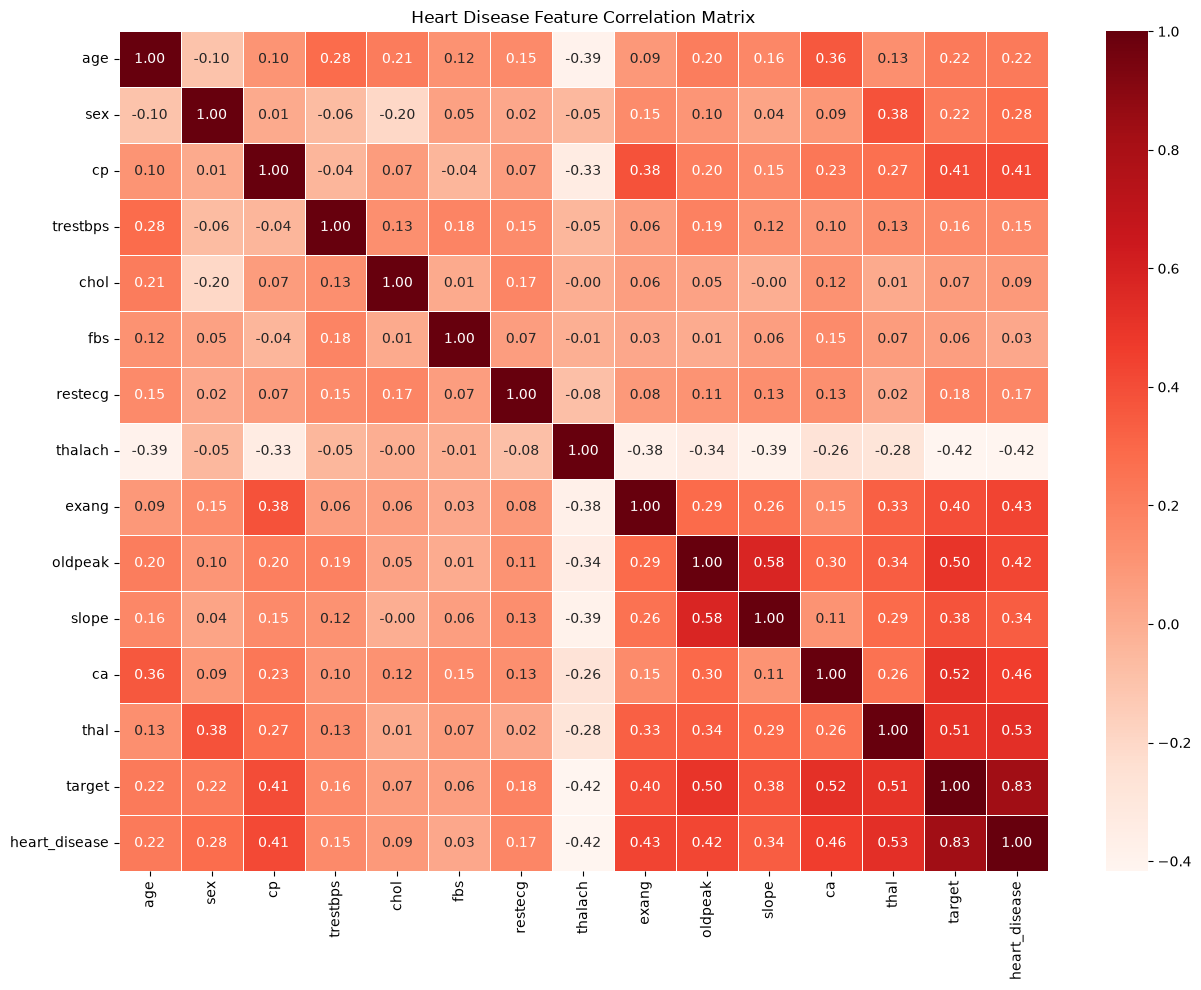

In [22]:
# Visualize relationships among numerical variables using a correlation heatmap

plt.figure(figsize=(13, 10))

sns.heatmap(
    correlation_matrix,
    cmap="Reds",
    annot=True,
    fmt=".2f",
    linewidths=0.4
)

plt.title("Heart Disease Feature Correlation Matrix")

plt.tight_layout()
plt.savefig("outputs/figures/correlation_heatmap.png", dpi=300)
plt.show()

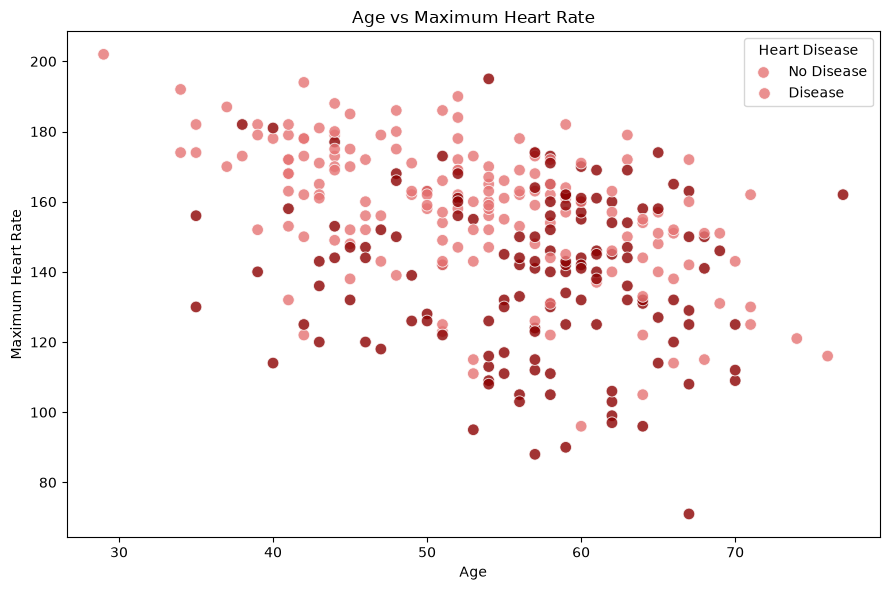

In [23]:
# Examine the relationship between age and maximum heart rate by diagnosis

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_eda,
    x="age",
    y="thalach",
    hue="heart_disease",
    palette=["#E57373", "#8B0000"],
    s=70,
    alpha=0.8
)

plt.title("Age vs Maximum Heart Rate")
plt.xlabel("Age")
plt.ylabel("Maximum Heart Rate")
plt.legend(title="Heart Disease", labels=["No Disease", "Disease"])

plt.tight_layout()
plt.savefig("outputs/figures/age_vs_max_heart_rate.png", dpi=300)
plt.show()

### EDA Insights

- The binary target distribution shows the relative representation of patients with and without diagnosed heart disease.
- Continuous clinical variables exhibit different distributions across the two diagnosis groups.
- The correlation matrix highlights relationships among cardiovascular measurements and the diagnosis variable.
- Age and maximum heart rate provide a useful two-dimensional representation of class overlap, which is particularly relevant when later examining SVM decision boundaries.
- The observed overlap between classes indicates that heart disease classification depends on a combination of clinical features rather than a single measurement.